✅ Libraries imported successfully!
✅ Data loaded successfully!
📊 Shape: 8793 rows × 23 columns

First few rows:


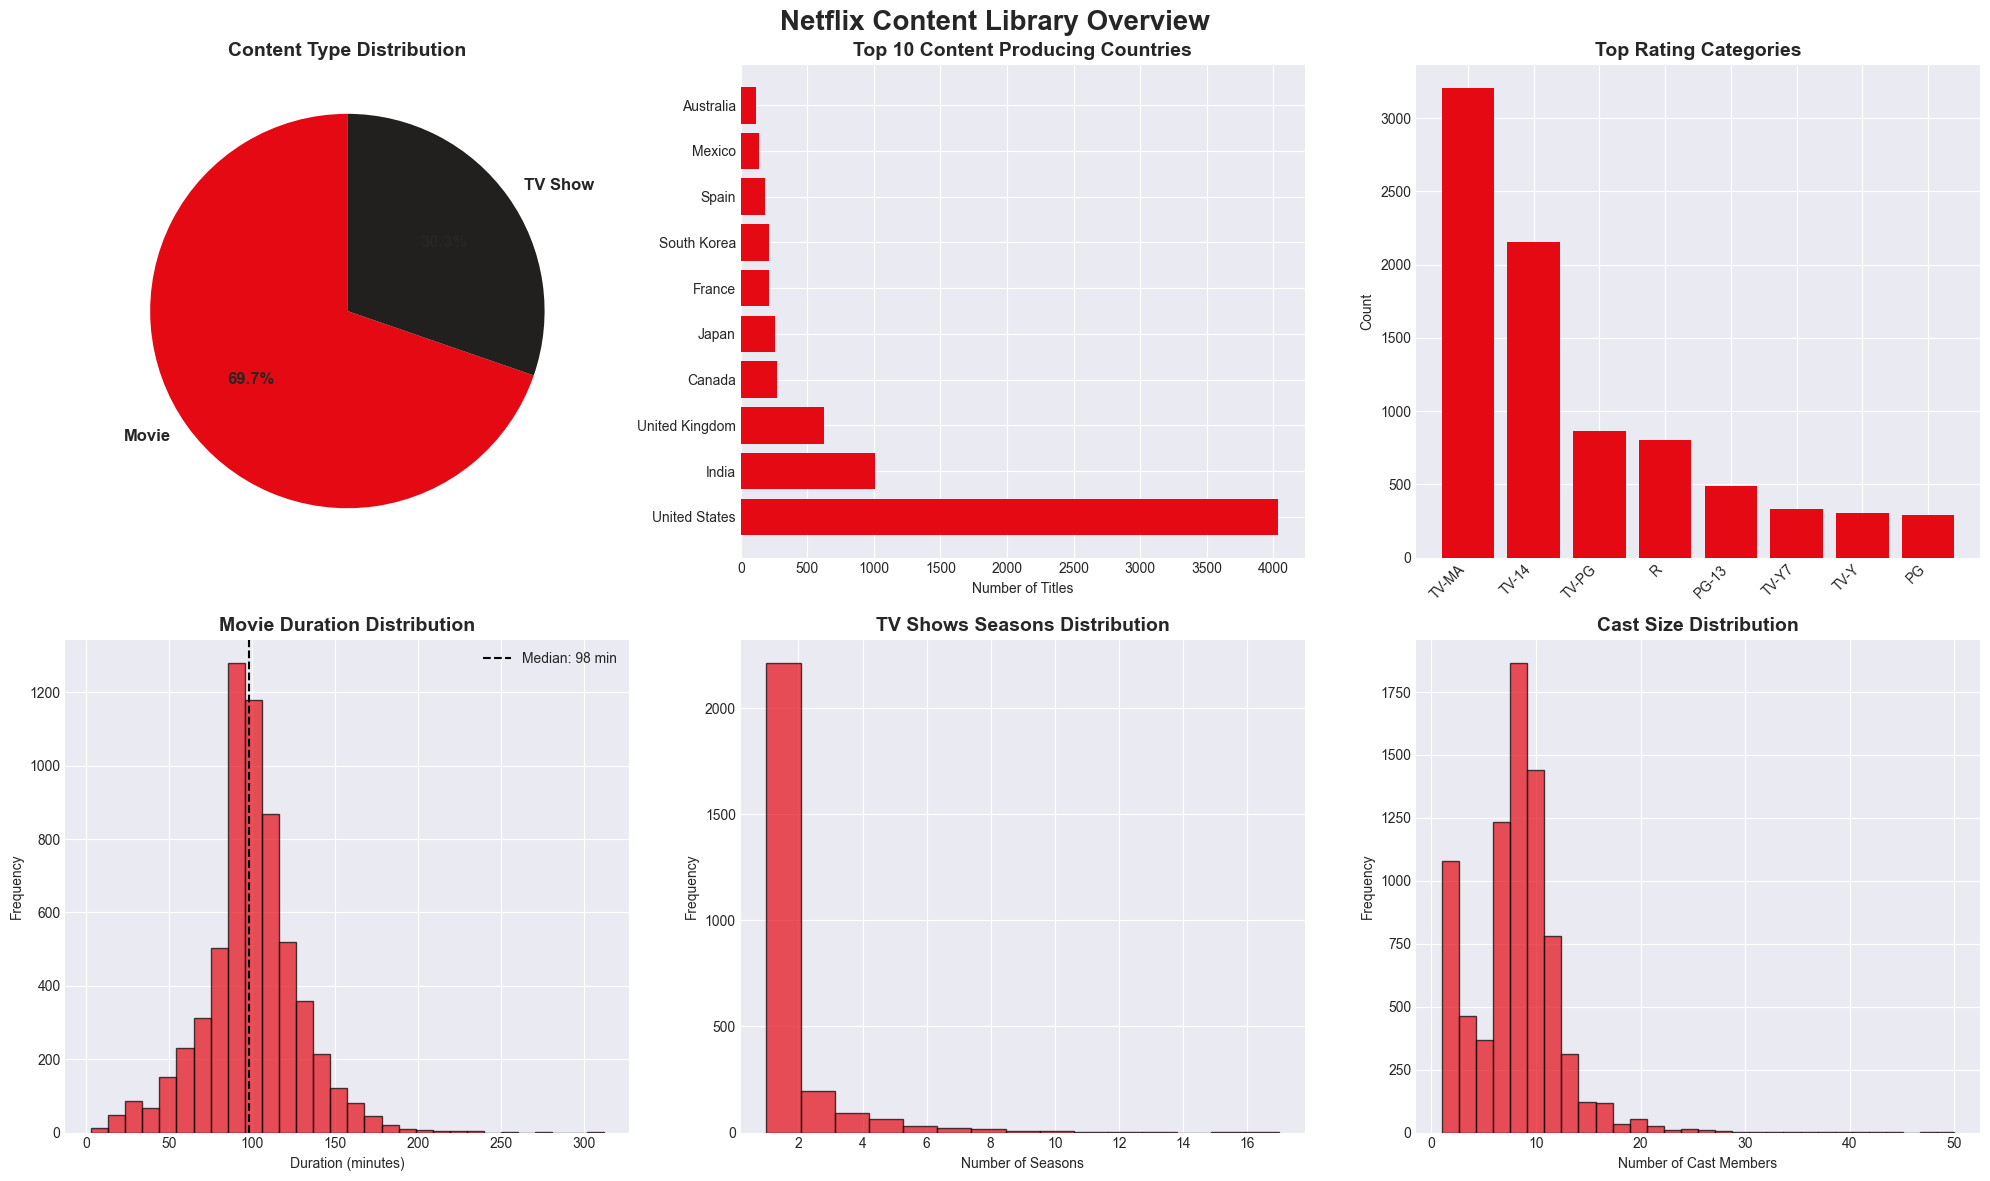

✅ Visualization created and saved!


In [2]:
# Cell 1: Import all libraries (RUN THIS FIRST!)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ Libraries imported successfully!")

# Cell 2: Set style and load data
# Set professional style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Reds")

# Load your cleaned data - using your correct path
df = pd.read_csv('D:/Netflix content strategy analysis/data/processed data/netflix_clean_data.csv')
print(f"✅ Data loaded successfully!")
print(f"📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nFirst few rows:")
df.head()

# Cell 3: Create the content overview visualization
# Create a professional figure
fig = plt.figure(figsize=(20, 12))
fig.suptitle('Netflix Content Library Overview', fontsize=20, fontweight='bold')

# 1. Content Type Distribution
ax1 = plt.subplot(2, 3, 1)
type_counts = df['type'].value_counts()
colors = ['#E50914', '#221f1f']  # Netflix colors
wedges, texts, autotexts = ax1.pie(type_counts.values, 
                                    labels=type_counts.index,
                                    autopct='%1.1f%%',
                                    colors=colors,
                                    startangle=90,
                                    textprops={'fontsize': 12, 'fontweight': 'bold'})
ax1.set_title('Content Type Distribution', fontsize=14, fontweight='bold')

# 2. Top 10 Countries
ax2 = plt.subplot(2, 3, 2)
# Make sure 'primary_country' column exists, if not use 'country'
country_col = 'primary_country' if 'primary_country' in df.columns else 'country'
top_countries = df[country_col].value_counts().head(10)
bars = ax2.barh(range(len(top_countries)), top_countries.values, color='#E50914')
ax2.set_yticks(range(len(top_countries)))
ax2.set_yticklabels(top_countries.index)
ax2.set_xlabel('Number of Titles')
ax2.set_title('Top 10 Content Producing Countries', fontsize=14, fontweight='bold')

# 3. Rating Distribution
ax3 = plt.subplot(2, 3, 3)
rating_counts = df['rating'].value_counts().head(8)
ax3.bar(range(len(rating_counts)), rating_counts.values, color='#E50914')
ax3.set_xticks(range(len(rating_counts)))
ax3.set_xticklabels(rating_counts.index, rotation=45, ha='right')
ax3.set_ylabel('Count')
ax3.set_title('Top Rating Categories', fontsize=14, fontweight='bold')

# 4. Movies Duration Distribution
ax4 = plt.subplot(2, 3, 4)
if 'duration_minutes' in df.columns:
    movies_duration = df[df['type'] == 'Movie']['duration_minutes'].dropna()
    if len(movies_duration) > 0:
        ax4.hist(movies_duration, bins=30, color='#E50914', edgecolor='black', alpha=0.7)
        ax4.set_xlabel('Duration (minutes)')
        ax4.set_ylabel('Frequency')
        ax4.set_title('Movie Duration Distribution', fontsize=14, fontweight='bold')
        ax4.axvline(movies_duration.median(), color='black', linestyle='--', 
                    label=f"Median: {movies_duration.median():.0f} min")
        ax4.legend()
else:
    ax4.text(0.5, 0.5, 'Duration data not available', 
             horizontalalignment='center', verticalalignment='center')

# 5. TV Shows Seasons Distribution
ax5 = plt.subplot(2, 3, 5)
if 'seasons' in df.columns:
    tv_seasons = df[df['type'] == 'TV Show']['seasons'].dropna()
    if len(tv_seasons) > 0:
        ax5.hist(tv_seasons, bins=15, color='#E50914', edgecolor='black', alpha=0.7)
        ax5.set_xlabel('Number of Seasons')
        ax5.set_ylabel('Frequency')
        ax5.set_title('TV Shows Seasons Distribution', fontsize=14, fontweight='bold')
else:
    ax5.text(0.5, 0.5, 'Seasons data not available', 
             horizontalalignment='center', verticalalignment='center')

# 6. Cast Size Distribution
ax6 = plt.subplot(2, 3, 6)
if 'cast_count' in df.columns:
    cast_size = df[df['cast'] != 'Unknown']['cast_count']
    if len(cast_size) > 0:
        ax6.hist(cast_size, bins=30, color='#E50914', edgecolor='black', alpha=0.7)
        ax6.set_xlabel('Number of Cast Members')
        ax6.set_ylabel('Frequency')
        ax6.set_title('Cast Size Distribution', fontsize=14, fontweight='bold')
else:
    ax6.text(0.5, 0.5, 'Cast count data not available', 
             horizontalalignment='center', verticalalignment='center')

plt.tight_layout()
plt.savefig('D:/Netflix content strategy analysis/outputs/figures/content_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualization created and saved!")